# All-in-One Evaluation Notebook for MILP Approaches

## Purpose

This notebook is the central place for documenting, running, and comparing different optimization approaches for the district heating problem.

The goal of this notebook is **evaluation**, not detailed development. Each new approach should be added here in a way that makes later comparison easy, fair, and readable.


## Problem Statement

We aim to minimize the operational cost of the district heating system while meeting heat demand and respecting all technical and market-related constraints.

The system consists of a heat pump, a condensing boiler, a CHP unit, and a thermal storage, while participating in the day-ahead electricity market.

The full mathematical formulation should be treated as the source of truth and referenced here:

- `docs/optimization/optimization_problem.md`


## Fundamental Notebook Rules

1. **This notebook is for comparison, not for messy exploration.**
2. **One code cell = one whole approach.**
3. Every approach must be understandable on its own, except for the shared setup defined above it.
4. No approach may change the input data.
5. Results must be recorded in a consistent format so that approaches can be compared later.
6. If a solver fails, times out, or returns an infeasible solution, that must be documented and not hidden.
7. The notebook should stay readable. Add approaches, do not rewrite previous ones without noting why.


## Practical Guidelines for Adding a New Approach

For each new approach, add exactly two cells:

- one **markdown cell** describing the approach
- one **code cell** containing the complete implementation of that approach

The markdown cell directly above an approach should always answer these questions:

- What is the name of the approach?
- What is the main idea?
- What is changed compared with the canonical problem formulation?
- How should it be interpreted against the shared evaluation baseline?
- What result or behavior do we expect?

The code cell directly below it should contain the full approach, including model setup, solve step, and result collection for that approach.


## Shared Setup

This section is reserved for everything that must be shared by all approaches.

It should contain only notebook-wide setup and no approach-specific logic.

Extract the shared setup from the canonical problem formulation and define it here once for the whole notebook.

Put here:

- imports
- time structure & index definition
- shared data loading
- shared inputs from the problem definition
- fixed parameters and common assumptions
- shared initial conditions
- shared rolling-horizon assumptions
- shared grid assumptions
- shared benchmark definitions
- shared helper functions
- common result storage
- shared plotting helpers

This section should make sure that all later approach cells work on the same common basis.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass, field
from time import perf_counter
import pyomo.environ as pyo

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120


def find_project_root(start: Path | None = None) -> Path:
    """Resolve the repository root so notebook paths work from different launch locations."""
    current = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing pyproject.toml and data/.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
DEMAND_FILE = DATA_DIR / "RawData_MeasuredHeadDemand.csv"
PRICE_FILE = DATA_DIR / "Gro_handelspreise_202403010000_202603020000_Stunde.csv"

In [2]:
@dataclass
class ModelParams:
    # Time settings
    dt: float = 0.25
    n_hours: int = 24

    # Prices and emissions
    gas_price: float = 35.0
    co2_factor: float = 0.201
    co2_price: float = 60.0

    # Storage
    sto_capacity: float = 200.0
    sto_charge_max: float = 15.0
    sto_discharge_max: float = 15.0
    sto_loss: float = 0.000125
    sto_soc_init: float = 200.0

    # Heat pump
    hp_p_el_min: float = 1.0
    hp_p_el_max: float = 8.0
    hp_cop: float = 3.5

    # Boiler
    boiler_q_min: float = 2.0
    boiler_q_max: float = 12.0
    boiler_eff: float = 0.97
    boiler_min_up: int = 4
    boiler_min_down: int = 4

    # CHP
    chp_p_el_min: float = 2.0
    chp_p_el_max: float = 6.0
    chp_eta_el: float = 0.40
    chp_eta_th: float = 0.48
    chp_min_up: int = 8
    chp_min_down: int = 8
    chp_startup_cost: float = 600.0

    # Optional optimization extensions (from your template)
    soc_target: float = 160.0
    lambda_term: float = 25.0
    use_hard_soc_min: bool = False
    soc_min: float = 120.0

    # Initial states
    hp_on_0: int = 0
    boiler_on_0: int = 0
    chp_on_0: int = 0
    soc_0: float = field(default=200.0)
    boiler_time_in_state_0: int = 0
    chp_time_in_state_0: int = 0

    # ---- Derived properties ----
    @property
    def fuel_cost(self):
        return self.gas_price + self.co2_factor * self.co2_price

    @property
    def n_steps(self):
        return int(self.n_hours / self.dt)

    @property
    def time_index(self):
        return range(1, self.n_steps + 1)

    @property
    def chp_th_per_el(self):
        return self.chp_eta_th / self.chp_eta_el

    @property
    def chp_q_th_min(self):
        return self.chp_th_per_el * self.chp_p_el_min

    @property
    def chp_q_th_max(self):
        return self.chp_th_per_el * self.chp_p_el_max

In [3]:
@dataclass
class ModelDataConfig:
    project_root: Path
    demand_file: Path
    price_file: Path

    result_columns: tuple[str, ...] = (
        "approach_name",
        "runtime_seconds",
        "notes",
    )

    results: pd.DataFrame = field(init=False)

    def __post_init__(self):
        self.results = pd.DataFrame(columns=self.result_columns)

    def get_price_column(self, columns: list[str]) -> str:
        """Select the Germany/Luxembourg DA price column from the SMARD export."""
        for column in columns:
            if column.startswith("Deutschland/Luxemburg [€/MWh]"):
                return column
        raise KeyError("Could not find a Germany/Luxembourg electricity price column.")

    def load_heat_demand(self) -> pd.DataFrame:
        """Load measured heat demand as an hourly UTC-indexed series in MW_th."""
        df = pd.read_csv(self.demand_file)
        df["timestamp"] = pd.to_datetime(df["Time Point"], utc=True)
        df["demand_mw_th"] = df["Measured Heat Demand[W]"] / 1e6

        return (
            df[["timestamp", "demand_mw_th"]]
            .set_index("timestamp")
            .sort_index()
        )

    def load_electricity_prices(self) -> pd.DataFrame:
        """Load day-ahead electricity prices as an hourly UTC-indexed series in EUR/MWh_el."""
        df = pd.read_csv(
            self.price_file,
            sep=";",
            decimal=",",
            low_memory=False,
        )

        price_column = self.get_price_column(df.columns.tolist())

        timestamps = pd.to_datetime(
            df["Datum von"],
            format="%d.%m.%Y %H:%M",
        )

        timestamps = timestamps.dt.tz_localize(
            "Europe/Berlin",
            ambiguous="infer",
            nonexistent="shift_forward",
        )

        df["timestamp"] = timestamps.dt.tz_convert("UTC")
        df["price_eur_mwh"] = df[price_column]

        return (
            df[["timestamp", "price_eur_mwh"]]
            .set_index("timestamp")
            .sort_index()
        )

    def expand_hourly_to_quarter_hour(
        self,
        values: pd.Series,
        params: ModelParams,
    ) -> np.ndarray:
        """Repeat each hourly value across the 15-minute intervals."""
        repeats_per_hour = int(1 / params.dt)
        return np.repeat(values.to_numpy(), repeats_per_hour)

    def prepare_single_day_inputs(
        self,
        params: ModelParams,
        heat_demand: pd.DataFrame,
        electricity_prices: pd.DataFrame,
        start_timestamp: pd.Timestamp | None = None,
    ) -> tuple[np.ndarray, np.ndarray, pd.DatetimeIndex, pd.Timestamp]:
        """Build one horizon-aligned input slice for the MILP."""
        common_index = heat_demand.index.intersection(electricity_prices.index).sort_values()
        if len(common_index) < params.n_hours:
            raise ValueError("Not enough overlapping hourly demand and price data for one horizon.")

        if start_timestamp is None:
            horizon_start = common_index[0]
        else:
            horizon_start = pd.Timestamp(start_timestamp)
            if horizon_start.tzinfo is None:
                horizon_start = horizon_start.tz_localize("UTC")
            else:
                horizon_start = horizon_start.tz_convert("UTC")

        if horizon_start not in common_index:
            raise ValueError("Requested start_timestamp is not available in both demand and price data.")

        start_pos = common_index.get_loc(horizon_start)
        horizon_hours = common_index[start_pos : start_pos + params.n_hours]
        if len(horizon_hours) != params.n_hours:
            raise ValueError("Not enough data after start_timestamp to cover the full horizon.")

        demand_hourly = heat_demand.loc[horizon_hours, "demand_mw_th"]
        price_hourly = electricity_prices.loc[horizon_hours, "price_eur_mwh"]
        quarter_hour_timestamps = pd.date_range(
            start=horizon_hours[0],
            periods=params.n_steps,
            freq=pd.to_timedelta(params.dt, unit="h"),
        )

        return (
            self.expand_hourly_to_quarter_hour(demand_hourly, params),
            self.expand_hourly_to_quarter_hour(price_hourly, params),
            quarter_hour_timestamps,
            horizon_hours[0],
        )

    def register_result(self, result: dict) -> None:
        """Append one standardized result row to the shared result table."""
        missing = [
            column for column in self.result_columns
            if column not in result
        ]

        if missing:
            raise ValueError(f"Result is missing required fields: {missing}")

        self.results.loc[len(self.results)] = [
            result[column] for column in self.result_columns
        ]

    def print_summary(self, params: ModelParams) -> None:
        print(f"Project root: {self.project_root}")
        print(f"Demand file: {self.demand_file.name}")
        print(f"Price file: {self.price_file.name}")
        print(f"Horizon: {params.n_steps} intervals at {params.dt} h")
        print(f"Effective gas cost: {params.fuel_cost:.2f} EUR/MWh_Hs")

In [4]:
params = ModelParams()

data_config = ModelDataConfig(
    project_root=PROJECT_ROOT,
    demand_file=DEMAND_FILE,
    price_file=PRICE_FILE,
)

heat_demand_raw = data_config.load_heat_demand()
electricity_prices_raw = data_config.load_electricity_prices()

heat_demand, electricity_prices, horizon_timestamps, horizon_start = data_config.prepare_single_day_inputs(
    params,
    heat_demand_raw,
    electricity_prices_raw,
)

RESULT_COLUMNS = [
    "approach_name",
    "runtime_seconds",
    "notes",
    "total_cost_eur",
    "profile",
]
RESULTS = pd.DataFrame(columns=RESULT_COLUMNS)


def build_result_profile(model, demand_th, timestamps) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "timestamp": pd.to_datetime(timestamps, utc=True),
            "heat_demand_mw_th": np.asarray(demand_th, dtype=float),
            "heat_supply_mw_th": [
                pyo.value(model.hp_th_out[t])
                + pyo.value(model.boiler_th_out[t])
                + pyo.value(model.chp_th_out[t])
                + pyo.value(model.sto_th_discharge[t])
                - pyo.value(model.sto_th_charge[t])
                for t in model.T
            ],
        }
    )


def upsert_result(approach_name, runtime_seconds, notes, total_cost_eur, profile) -> None:
    global RESULTS
    RESULTS = RESULTS.loc[RESULTS["approach_name"] != approach_name].reset_index(drop=True)
    RESULTS.loc[len(RESULTS)] = {
        "approach_name": approach_name,
        "runtime_seconds": runtime_seconds,
        "notes": notes,
        "total_cost_eur": total_cost_eur,
        "profile": profile,
    }


data_config.print_summary(params)
print(f"Selected horizon start: {horizon_start}")
print(f"Prepared vectors: demand={len(heat_demand)}, price={len(electricity_prices)}")

Project root: c:\Users\Nikla\VSCode Projects\datascience
Demand file: RawData_MeasuredHeadDemand.csv
Price file: Gro_handelspreise_202403010000_202603020000_Stunde.csv
Horizon: 96 intervals at 0.25 h
Effective gas cost: 47.06 EUR/MWh_Hs
Selected horizon start: 2024-02-29 23:00:00+00:00
Prepared vectors: demand=96, price=96


## Evaluation Agreement

Before approaches are compared, we should agree on a common evaluation baseline outside the individual approach cells.

Once that baseline is fixed, it should be documented here and applied to every approach in the notebook.

This section should later define at least:

- the benchmark instances or days
- the reported evaluation metrics


## Required Output of Each Approach

Each approach should later produce results in a consistent structure so that the final evaluation section can compare them cleanly.

Suggested minimum fields:

- `approach_name`
- `runtime_seconds`
- `notes`

Recommended optional fields for the comparison plot:

- `total_cost_eur`
- `profile`: a `pd.DataFrame` with `timestamp`, `heat_demand_mw_th`, and `heat_supply_mw_th`


## Approach Template

Copy the following pattern whenever a new approach is added.

If more approaches are tested later, duplicate one markdown-code pair and append it below the last approach section.

**Markdown cell template:**

- **Approach name:**
- **Main idea:**
- **Difference to canonical problem formulation:**
- **Interpretation against evaluation baseline:**
- **Expectation:**

**Code cell template:**

- build the full model for this approach
- solve it
- collect outputs in the agreed result format
- store or display the results clearly


## Approach 1

- **Approach name:** Standard MILP
- **Main idea:**
- **Difference to canonical problem formulation:**
- **Interpretation against evaluation baseline:**
- **Expectation:**


In [5]:
def add_min_up_down_constraints(model, on_var, start_var, stop_var, min_up, min_down, prefix):
    # Minimum up-time: once started, the unit must remain on for a fixed number of steps.
    if min_up > 0:
        def min_up_rule(m, t):
            start_idx = max(0, t - min_up + 1)
            return sum(start_var[i] for i in range(start_idx, t + 1)) <= on_var[t]
        model.add_component(f'{prefix}_min_up', pyo.Constraint(model.T, rule=min_up_rule))

    # Minimum down-time: once stopped, the unit must remain off for a fixed number of steps.
    if min_down > 0:
        def min_down_rule(m, t):
            start_idx = max(0, t - min_down + 1)
            return sum(stop_var[i] for i in range(start_idx, t + 1)) <= 1 - on_var[t]
        model.add_component(f'{prefix}_min_down', pyo.Constraint(model.T, rule=min_down_rule))


def build_model(params, demand_th, price_el):
    if len(demand_th) != params.n_steps or len(price_el) != params.n_steps:
        raise ValueError('Inputs must have length params.n_steps')

    m = pyo.ConcreteModel('DistrictHeatingMILP')
    m.T = pyo.RangeSet(0, params.n_steps - 1)
    m.demand_th = pyo.Param(m.T, initialize={t: float(demand_th[t]) for t in range(params.n_steps)})
    m.price_el = pyo.Param(m.T, initialize={t: float(price_el[t]) for t in range(params.n_steps)})

    # Binary commitment variables.
    m.hp_on = pyo.Var(m.T, domain=pyo.Binary)
    m.boiler_on = pyo.Var(m.T, domain=pyo.Binary)
    m.chp_on = pyo.Var(m.T, domain=pyo.Binary)
    m.boiler_start = pyo.Var(m.T, domain=pyo.Binary)
    m.boiler_stop = pyo.Var(m.T, domain=pyo.Binary)
    m.chp_start = pyo.Var(m.T, domain=pyo.Binary)
    m.chp_stop = pyo.Var(m.T, domain=pyo.Binary)
    m.sto_mode_charge = pyo.Var(m.T, domain=pyo.Binary)

    # Continuous dispatch and storage variables.
    m.hp_el_in = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.hp_th_out = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.boiler_th_out = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.boiler_fuel_in = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.chp_el_out = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.chp_th_out = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.chp_fuel_in = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.sto_th_charge = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.sto_th_discharge = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.sto_th_soc = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.sto_th_shortfall = pyo.Var(domain=pyo.NonNegativeReals)

    # Heat balance: total supplied heat minus storage charging must match demand each step.
    m.heat_balance = pyo.Constraint(
        m.T,
        rule=lambda mm, t: mm.hp_th_out[t] + mm.boiler_th_out[t] + mm.chp_th_out[t] + mm.sto_th_discharge[t] - mm.sto_th_charge[t] == mm.demand_th[t],
    )


    # Storage capacity bound.
    m.sto_soc_bound = pyo.Constraint(m.T, rule=lambda mm, t: mm.sto_th_soc[t] <= params.sto_capacity)

    # Storage mode logic: only charge when in charge mode.
    m.sto_charge_limit = pyo.Constraint(m.T, rule=lambda mm, t: mm.sto_th_charge[t] <= params.sto_charge_max * mm.sto_mode_charge[t])

    # Storage mode logic: only discharge when not in charge mode.
    m.sto_discharge_limit = pyo.Constraint(m.T, rule=lambda mm, t: mm.sto_th_discharge[t] <= params.sto_discharge_max * (1 - mm.sto_mode_charge[t]))

    # Storage dynamics: state of charge evolves with charge, discharge, and standing loss.
    def soc_rule(mm, t):
        prev_soc = params.sto_soc_init if t == 0 else mm.sto_th_soc[t - 1]
        return mm.sto_th_soc[t] == prev_soc + params.dt * mm.sto_th_charge[t] - params.dt * mm.sto_th_discharge[t] - params.sto_loss
    m.sto_soc_dynamics = pyo.Constraint(m.T, rule=soc_rule)
    

    # Heat pump operating window when committed.
    m.hp_min = pyo.Constraint(m.T, rule=lambda mm, t: params.hp_p_el_min * mm.hp_on[t] <= mm.hp_el_in[t])
    m.hp_max = pyo.Constraint(m.T, rule=lambda mm, t: mm.hp_el_in[t] <= params.hp_p_el_max * mm.hp_on[t])

    # Heat pump conversion: thermal output equals COP times electrical input.
    m.hp_cop = pyo.Constraint(m.T, rule=lambda mm, t: mm.hp_th_out[t] == params.hp_cop * mm.hp_el_in[t])


    # Boiler operating window when committed.
    m.boiler_min = pyo.Constraint(m.T, rule=lambda mm, t: params.boiler_q_min * mm.boiler_on[t] <= mm.boiler_th_out[t])
    m.boiler_max = pyo.Constraint(m.T, rule=lambda mm, t: mm.boiler_th_out[t] <= params.boiler_q_max * mm.boiler_on[t])

    # Boiler fuel conversion: thermal output is linked to fuel input by efficiency.
    m.boiler_eta = pyo.Constraint(m.T, rule=lambda mm, t: mm.boiler_fuel_in[t] * params.boiler_eff == mm.boiler_th_out[t])

    # Boiler startup indicator: becomes active when the boiler switches on.
    m.boiler_start_logic = pyo.Constraint(m.T, rule=lambda mm, t: mm.boiler_start[t] >= mm.boiler_on[t] - (params.boiler_on_0 if t == 0 else mm.boiler_on[t - 1]))

    # Boiler shutdown indicator: becomes active when the boiler switches off.
    m.boiler_stop_logic = pyo.Constraint(m.T, rule=lambda mm, t: mm.boiler_stop[t] >= (params.boiler_on_0 if t == 0 else mm.boiler_on[t - 1]) - mm.boiler_on[t])
    add_min_up_down_constraints(m, m.boiler_on, m.boiler_start, m.boiler_stop, params.boiler_min_up, params.boiler_min_down, 'boiler')


    # CHP operating window when committed.
    m.chp_min = pyo.Constraint(m.T, rule=lambda mm, t: params.chp_p_el_min * mm.chp_on[t] <= mm.chp_el_out[t])
    m.chp_max = pyo.Constraint(m.T, rule=lambda mm, t: mm.chp_el_out[t] <= params.chp_p_el_max * mm.chp_on[t])

    # CHP heat-power coupling: thermal output is proportional to electrical output.
    m.chp_heat = pyo.Constraint(m.T, rule=lambda mm, t: mm.chp_th_out[t] == params.chp_th_per_el * mm.chp_el_out[t])

    # CHP fuel conversion: electrical output is linked to fuel input by electrical efficiency.
    m.chp_eta = pyo.Constraint(m.T, rule=lambda mm, t: mm.chp_fuel_in[t] * params.chp_eta_el == mm.chp_el_out[t])

    # CHP startup indicator: becomes active when the CHP switches on.
    m.chp_start_logic = pyo.Constraint(m.T, rule=lambda mm, t: mm.chp_start[t] >= mm.chp_on[t] - (params.chp_on_0 if t == 0 else mm.chp_on[t - 1]))

    # CHP shutdown indicator: becomes active when the CHP switches off.
    m.chp_stop_logic = pyo.Constraint(m.T, rule=lambda mm, t: mm.chp_stop[t] >= (params.chp_on_0 if t == 0 else mm.chp_on[t - 1]) - mm.chp_on[t])
    add_min_up_down_constraints(m, m.chp_on, m.chp_start, m.chp_stop, params.chp_min_up, params.chp_min_down, 'chp')

    # Objective: operating cost plus startup cost minus CHP power market revenue plus terminal storage penalty.
    m.objective = pyo.Objective(
        expr=sum(
            m.hp_el_in[t] * m.price_el[t] * params.dt
            + m.boiler_fuel_in[t] * params.fuel_cost * params.dt
            + m.chp_fuel_in[t] * params.fuel_cost * params.dt
            + params.chp_startup_cost * m.chp_start[t]
            - m.chp_el_out[t] * m.price_el[t] * params.dt
            for t in m.T
        ),
        sense=pyo.minimize,
    )

    return m

approach_name = 'Approach 1 - Standard MILP'
started_at = perf_counter()
model = build_model(params, heat_demand, electricity_prices)
solver = pyo.SolverFactory('appsi_highs')
result = solver.solve(model)
runtime_seconds = perf_counter() - started_at
termination_condition = str(result.solver.termination_condition)
total_cost_eur = pyo.value(model.objective)
profile = build_result_profile(model, heat_demand, horizon_timestamps)
upsert_result(
    approach_name=approach_name,
    runtime_seconds=runtime_seconds,
    notes=f'Termination condition: {termination_condition}',
    total_cost_eur=total_cost_eur,
    profile=profile,
)
print('Termination condition:', termination_condition)
print(f'Total cost: {total_cost_eur:.2f} EUR')
print(RESULTS[['approach_name', 'runtime_seconds', 'total_cost_eur']])

Termination condition: optimal
Total cost: -0.00 EUR
                approach_name  runtime_seconds  total_cost_eur
0  Approach 1 - Standard MILP          0.54077   -3.916232e-14


## Approach 2

- **Approach name:** Standard MILP with EoD Storage penalty
- **Main idea:**
- **Difference to canonical problem formulation:**
- **Interpretation against evaluation baseline:**
- **Expectation:**


In [6]:
def add_min_up_down_constraints(model, on_var, start_var, stop_var, min_up, min_down, prefix):
    # Minimum up-time: once started, the unit must remain on for a fixed number of steps.
    if min_up > 0:
        def min_up_rule(m, t):
            start_idx = max(0, t - min_up + 1)
            return sum(start_var[i] for i in range(start_idx, t + 1)) <= on_var[t]
        model.add_component(f'{prefix}_min_up', pyo.Constraint(model.T, rule=min_up_rule))

    # Minimum down-time: once stopped, the unit must remain off for a fixed number of steps.
    if min_down > 0:
        def min_down_rule(m, t):
            start_idx = max(0, t - min_down + 1)
            return sum(stop_var[i] for i in range(start_idx, t + 1)) <= 1 - on_var[t]
        model.add_component(f'{prefix}_min_down', pyo.Constraint(model.T, rule=min_down_rule))


def build_model(params, demand_th, price_el):
    if len(demand_th) != params.n_steps or len(price_el) != params.n_steps:
        raise ValueError('Inputs must have length params.n_steps')

    m = pyo.ConcreteModel('DistrictHeatingMILP')
    m.T = pyo.RangeSet(0, params.n_steps - 1)
    m.demand_th = pyo.Param(m.T, initialize={t: float(demand_th[t]) for t in range(params.n_steps)})
    m.price_el = pyo.Param(m.T, initialize={t: float(price_el[t]) for t in range(params.n_steps)})

    # Binary commitment variables.
    m.hp_on = pyo.Var(m.T, domain=pyo.Binary)
    m.boiler_on = pyo.Var(m.T, domain=pyo.Binary)
    m.chp_on = pyo.Var(m.T, domain=pyo.Binary)
    m.boiler_start = pyo.Var(m.T, domain=pyo.Binary)
    m.boiler_stop = pyo.Var(m.T, domain=pyo.Binary)
    m.chp_start = pyo.Var(m.T, domain=pyo.Binary)
    m.chp_stop = pyo.Var(m.T, domain=pyo.Binary)
    m.sto_mode_charge = pyo.Var(m.T, domain=pyo.Binary)

    # Continuous dispatch and storage variables.
    m.hp_el_in = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.hp_th_out = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.boiler_th_out = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.boiler_fuel_in = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.chp_el_out = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.chp_th_out = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.chp_fuel_in = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.sto_th_charge = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.sto_th_discharge = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.sto_th_soc = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.sto_th_shortfall = pyo.Var(domain=pyo.NonNegativeReals)

    # Heat balance: total supplied heat minus storage charging must match demand each step.
    m.heat_balance = pyo.Constraint(
        m.T,
        rule=lambda mm, t: mm.hp_th_out[t] + mm.boiler_th_out[t] + mm.chp_th_out[t] + mm.sto_th_discharge[t] - mm.sto_th_charge[t] == mm.demand_th[t],
    )


    # Storage capacity bound.
    m.sto_soc_bound = pyo.Constraint(m.T, rule=lambda mm, t: mm.sto_th_soc[t] <= params.sto_capacity)

    # Storage mode logic: only charge when in charge mode.
    m.sto_charge_limit = pyo.Constraint(m.T, rule=lambda mm, t: mm.sto_th_charge[t] <= params.sto_charge_max * mm.sto_mode_charge[t])

    # Storage mode logic: only discharge when not in charge mode.
    m.sto_discharge_limit = pyo.Constraint(m.T, rule=lambda mm, t: mm.sto_th_discharge[t] <= params.sto_discharge_max * (1 - mm.sto_mode_charge[t]))

    # Storage dynamics: state of charge evolves with charge, discharge, and standing loss.
    def soc_rule(mm, t):
        prev_soc = params.sto_soc_init if t == 0 else mm.sto_th_soc[t - 1]
        return mm.sto_th_soc[t] == prev_soc + params.dt * mm.sto_th_charge[t] - params.dt * mm.sto_th_discharge[t] - params.sto_loss
    m.sto_soc_dynamics = pyo.Constraint(m.T, rule=soc_rule)

    # Soft terminal condition: penalize ending below the target storage level.
    m.sto_terminal_shortfall = pyo.Constraint(expr=m.sto_th_shortfall >= params.soc_target - m.sto_th_soc[params.n_steps - 1])

    # Optional hard terminal condition: enforce a minimum end-of-horizon storage level.
    if params.use_hard_soc_min:
        m.sto_terminal_min = pyo.Constraint(expr=m.sto_th_soc[params.n_steps - 1] >= params.soc_min)


    # Heat pump operating window when committed.
    m.hp_min = pyo.Constraint(m.T, rule=lambda mm, t: params.hp_p_el_min * mm.hp_on[t] <= mm.hp_el_in[t])
    m.hp_max = pyo.Constraint(m.T, rule=lambda mm, t: mm.hp_el_in[t] <= params.hp_p_el_max * mm.hp_on[t])

    # Heat pump conversion: thermal output equals COP times electrical input.
    m.hp_cop = pyo.Constraint(m.T, rule=lambda mm, t: mm.hp_th_out[t] == params.hp_cop * mm.hp_el_in[t])


    # Boiler operating window when committed.
    m.boiler_min = pyo.Constraint(m.T, rule=lambda mm, t: params.boiler_q_min * mm.boiler_on[t] <= mm.boiler_th_out[t])
    m.boiler_max = pyo.Constraint(m.T, rule=lambda mm, t: mm.boiler_th_out[t] <= params.boiler_q_max * mm.boiler_on[t])

    # Boiler fuel conversion: thermal output is linked to fuel input by efficiency.
    m.boiler_eta = pyo.Constraint(m.T, rule=lambda mm, t: mm.boiler_fuel_in[t] * params.boiler_eff == mm.boiler_th_out[t])

    # Boiler startup indicator: becomes active when the boiler switches on.
    m.boiler_start_logic = pyo.Constraint(m.T, rule=lambda mm, t: mm.boiler_start[t] >= mm.boiler_on[t] - (params.boiler_on_0 if t == 0 else mm.boiler_on[t - 1]))

    # Boiler shutdown indicator: becomes active when the boiler switches off.
    m.boiler_stop_logic = pyo.Constraint(m.T, rule=lambda mm, t: mm.boiler_stop[t] >= (params.boiler_on_0 if t == 0 else mm.boiler_on[t - 1]) - mm.boiler_on[t])
    add_min_up_down_constraints(m, m.boiler_on, m.boiler_start, m.boiler_stop, params.boiler_min_up, params.boiler_min_down, 'boiler')


    # CHP operating window when committed.
    m.chp_min = pyo.Constraint(m.T, rule=lambda mm, t: params.chp_p_el_min * mm.chp_on[t] <= mm.chp_el_out[t])
    m.chp_max = pyo.Constraint(m.T, rule=lambda mm, t: mm.chp_el_out[t] <= params.chp_p_el_max * mm.chp_on[t])

    # CHP heat-power coupling: thermal output is proportional to electrical output.
    m.chp_heat = pyo.Constraint(m.T, rule=lambda mm, t: mm.chp_th_out[t] == params.chp_th_per_el * mm.chp_el_out[t])

    # CHP fuel conversion: electrical output is linked to fuel input by electrical efficiency.
    m.chp_eta = pyo.Constraint(m.T, rule=lambda mm, t: mm.chp_fuel_in[t] * params.chp_eta_el == mm.chp_el_out[t])

    # CHP startup indicator: becomes active when the CHP switches on.
    m.chp_start_logic = pyo.Constraint(m.T, rule=lambda mm, t: mm.chp_start[t] >= mm.chp_on[t] - (params.chp_on_0 if t == 0 else mm.chp_on[t - 1]))

    # CHP shutdown indicator: becomes active when the CHP switches off.
    m.chp_stop_logic = pyo.Constraint(m.T, rule=lambda mm, t: mm.chp_stop[t] >= (params.chp_on_0 if t == 0 else mm.chp_on[t - 1]) - mm.chp_on[t])
    add_min_up_down_constraints(m, m.chp_on, m.chp_start, m.chp_stop, params.chp_min_up, params.chp_min_down, 'chp')

    # Objective: operating cost plus startup cost minus CHP power market revenue plus terminal storage penalty.
    m.objective = pyo.Objective(
        expr=sum(
            m.hp_el_in[t] * m.price_el[t] * params.dt
            + m.boiler_fuel_in[t] * params.fuel_cost * params.dt
            + m.chp_fuel_in[t] * params.fuel_cost * params.dt
            + params.chp_startup_cost * m.chp_start[t]
            - m.chp_el_out[t] * m.price_el[t] * params.dt
            for t in m.T
        ) + params.lambda_term * m.sto_th_shortfall,
        sense=pyo.minimize,
    )

    return m

approach_name = 'Approach 2 - MILP with terminal storage penalty'
started_at = perf_counter()
model = build_model(params, heat_demand, electricity_prices)
solver = pyo.SolverFactory('appsi_highs')
result = solver.solve(model)
runtime_seconds = perf_counter() - started_at
termination_condition = str(result.solver.termination_condition)
total_cost_eur = pyo.value(model.objective)
profile = build_result_profile(model, heat_demand, horizon_timestamps)
upsert_result(
    approach_name=approach_name,
    runtime_seconds=runtime_seconds,
    notes=f'Termination condition: {termination_condition}',
    total_cost_eur=total_cost_eur,
    profile=profile,
)
print('Termination condition:', termination_condition)
print(f'Total cost: {total_cost_eur:.2f} EUR')
print(RESULTS[['approach_name', 'runtime_seconds', 'total_cost_eur']])


Termination condition: optimal
Total cost: 2421.74 EUR
                                     approach_name  runtime_seconds  \
0                       Approach 1 - Standard MILP         0.540770   
1  Approach 2 - MILP with terminal storage penalty         0.882679   

   total_cost_eur  
0   -3.916232e-14  
1    2.421739e+03  


## Approach 3

- **Approach name:**
- **Main idea:**
- **Difference to canonical problem formulation:**
- **Interpretation against evaluation baseline:**
- **Expectation:**


In [7]:
# One code cell = one whole approach.
#
# Place the complete implementation of Approach 3 here later.
# The full approach should live in this single cell.


## Evaluation and Comparison

This section is reserved for the final comparison once multiple approaches have been added.

Later, summarize here:

- which approaches were run
- how each approach performed against the agreed evaluation baseline
- which metrics are compared
- which results are still preliminary


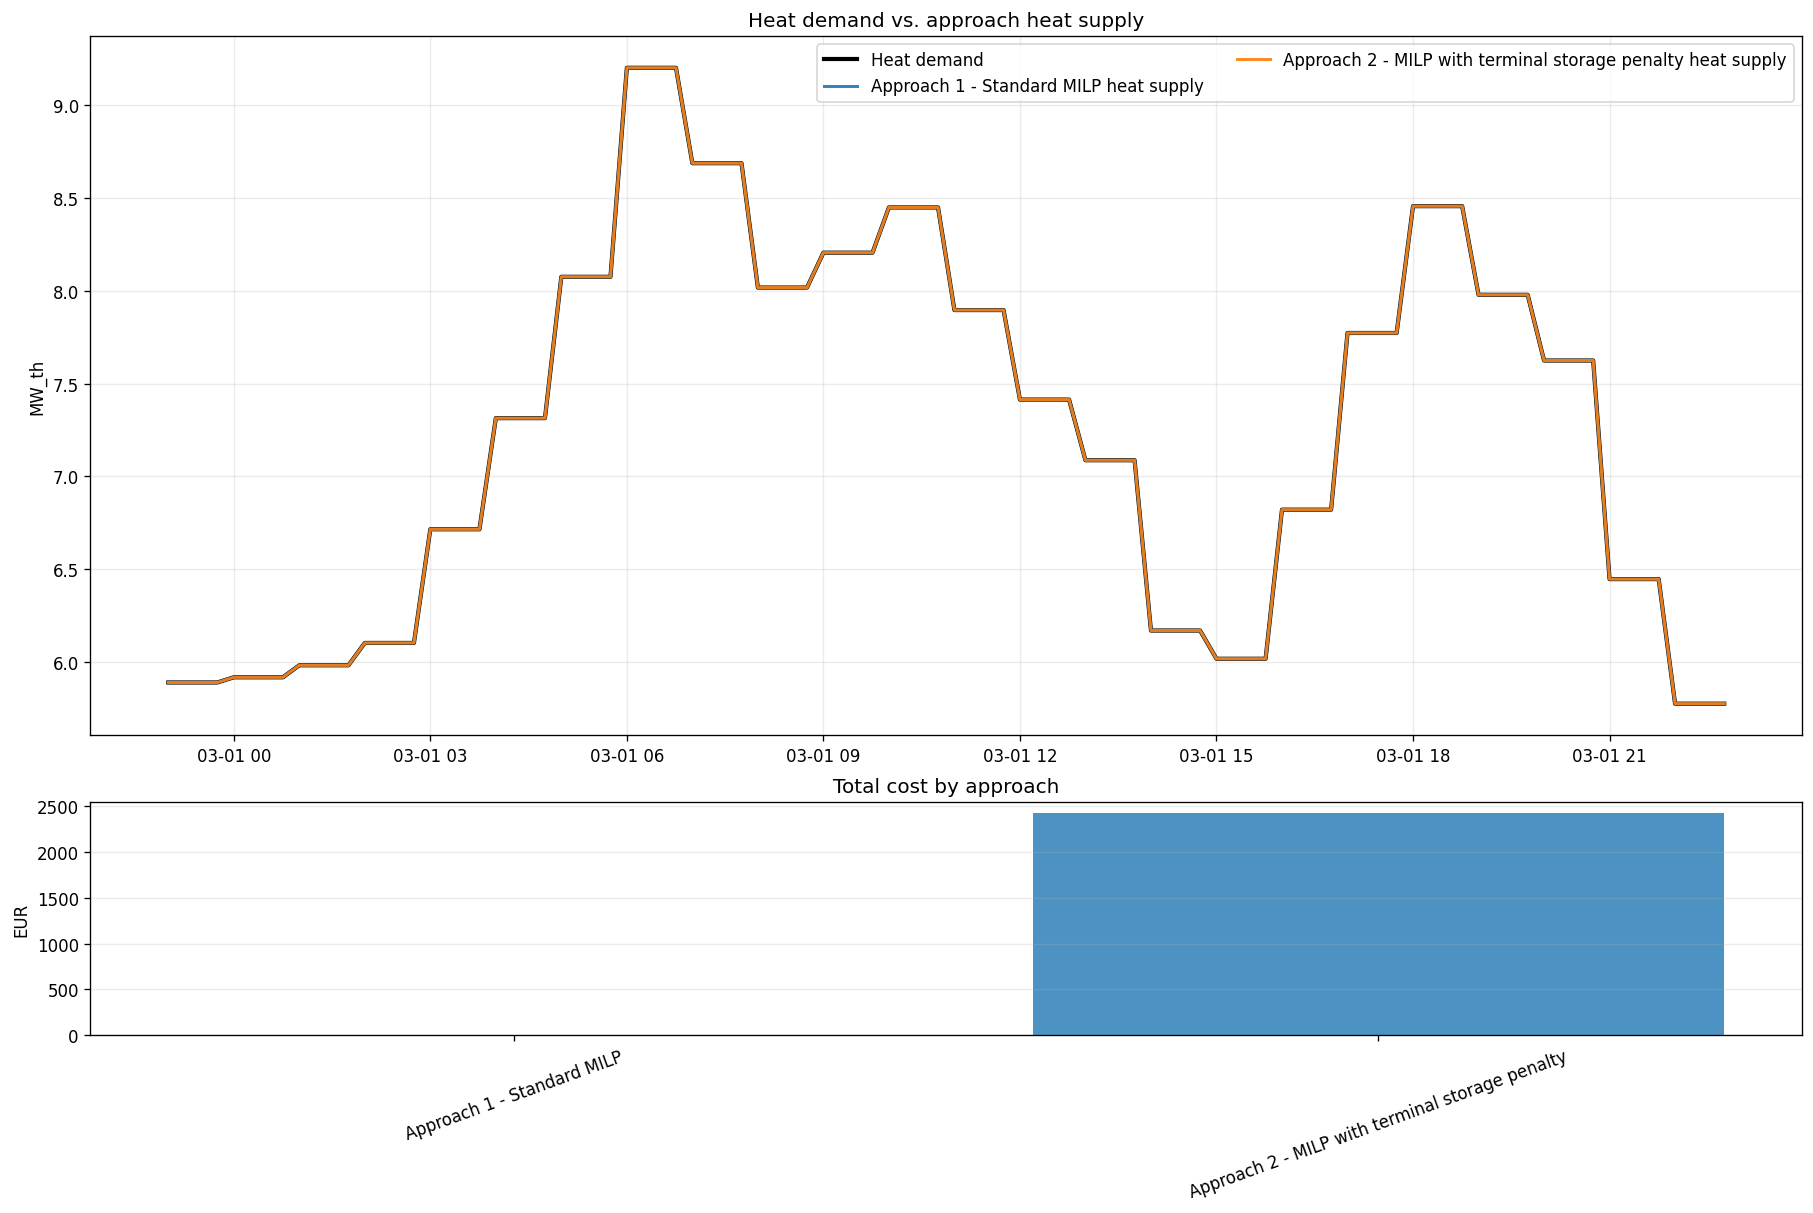

In [8]:
if RESULTS.empty:
    print("No approach results registered yet.")
else:
    profiles = []
    cost_rows = []

    for _, row in RESULTS.iterrows():
        profile = row.get("profile")
        if isinstance(profile, pd.DataFrame) and not profile.empty:
            labeled_profile = profile.copy()
            labeled_profile["approach_name"] = row["approach_name"]
            profiles.append(labeled_profile)

        total_cost = row.get("total_cost_eur")
        if pd.notna(total_cost):
            cost_rows.append(
                {
                    "approach_name": row["approach_name"],
                    "total_cost_eur": float(total_cost),
                }
            )

    if not profiles and not cost_rows:
        print("Registered results are missing both profile and total_cost_eur data.")
    else:
        fig, axes = plt.subplots(
            2,
            1,
            figsize=(15, 10),
            gridspec_kw={"height_ratios": [3, 1]},
            constrained_layout=True,
        )

        if profiles:
            comparison = pd.concat(profiles, ignore_index=True)
            demand = comparison[["timestamp", "heat_demand_mw_th"]].drop_duplicates().sort_values("timestamp")

            axes[0].plot(
                demand["timestamp"],
                demand["heat_demand_mw_th"],
                color="black",
                linewidth=2.5,
                label="Heat demand",
            )

            for approach_name, frame in comparison.groupby("approach_name"):
                frame = frame.sort_values("timestamp")
                axes[0].plot(
                    frame["timestamp"],
                    frame["heat_supply_mw_th"],
                    linewidth=1.8,
                    alpha=0.9,
                    label=f"{approach_name} heat supply",
                )

            axes[0].set_title("Heat demand vs. approach heat supply")
            axes[0].set_ylabel("MW_th")
            axes[0].grid(alpha=0.25)
            axes[0].legend(loc="upper right", ncol=2)
        else:
            axes[0].text(0.5, 0.5, "No profile data available.", ha="center", va="center")
            axes[0].set_axis_off()

        if cost_rows:
            cost_df = pd.DataFrame(cost_rows).sort_values("total_cost_eur")
            axes[1].bar(cost_df["approach_name"], cost_df["total_cost_eur"], color="tab:blue", alpha=0.8)
            axes[1].set_title("Total cost by approach")
            axes[1].set_ylabel("EUR")
            axes[1].grid(axis="y", alpha=0.25)
            axes[1].tick_params(axis="x", rotation=20)
        else:
            axes[1].text(0.5, 0.5, "No total_cost_eur data available.", ha="center", va="center")
            axes[1].set_axis_off()

        plt.show()
